In [1]:
import numpy as np
from PIL import Image as PILImage, ImageDraw
from enum import Enum
import random
import gymnasium as gym


# Definitions
class LightColor(Enum):
    RED = 0
    YELLOW = 1
    GREEN = 2


class Cell(Enum):
    ROAD = 0
    HOUSE = 1
    TRAFFIC = 2
    HOSPITAL = 3
    CAR = 4


class GridAction(Enum):
    LEFT = 0
    DOWN = 1
    RIGHT = 2
    UP = 3


# Environment
class SmartAmbulanceEnv(gym.Env):
    """
    Custom Gymnasium Environment for a Smart Ambulance pathfinding task.

    Attributes:
        size (int): Grid dimensions (size x size).
        _grid (numpy.ndarray): 2D array representing the map layout.
        traffic_lights (dict): Stores (r, c) positions and current [LightColor, timer].
        car_positions (set): Current coordinates of dynamic car obstacles.
        car_move_rate (int): Frequency of car movements (every N steps).
    """

    def __init__(self, size=20, seed=69):
        self.size = size
        self.rows = size
        self.cols = size
        self._state = 0

        random.seed(seed)
        np.random.seed(seed)

        self._grid = np.zeros((size, size), dtype=int)
        self.car_move_counter = 0
        self.car_move_rate = 3  # Every how many steps cars move

        # Houses
        for _ in range(20):
            r, c = random.randint(0, size - 1), random.randint(0, size - 1)
            if (r, c) != (0, 0) and (r, c) != (size - 1, size - 1):
                self._grid[r, c] = Cell.HOUSE.value

        # Moving Cars
        for _ in range(10):
            r, c = random.randint(0, size - 1), random.randint(0, size - 1)
            if self._grid[r, c] == Cell.ROAD.value and (r, c) != (0, 0):
                self._grid[r, c] = Cell.CAR.value

        # Save Car Positions
        self.car_positions = set()
        for r in range(size):
            for c in range(size):
                if self._grid[r, c] == Cell.CAR.value:
                    self.car_positions.add((r, c))

        # Traffic Lights
        self.traffic_lights = {}
        for _ in range(15):
            r, c = random.randint(0, size - 1), random.randint(0, size - 1)
            if self._grid[r, c] == Cell.ROAD.value and (r, c) != (0, 0):
                self._grid[r, c] = Cell.TRAFFIC.value
                self.traffic_lights[(r, c)] = [random.choice(list(LightColor)), 0]

        self._grid[size - 1, size - 1] = Cell.HOSPITAL.value

        self.observation_space = gym.spaces.Discrete(size * size)
        self.action_space = gym.spaces.Discrete(len(GridAction))

    def update_lights(self):
        """Updates the state and timers of all traffic lights in the grid."""
        for loc in self.traffic_lights:
            color, counter = self.traffic_lights[loc]
            counter += 1
            limit = (
                10
                if color == LightColor.GREEN
                else 5 if color == LightColor.YELLOW else 10
            )
            if counter >= limit:
                next_c = (
                    LightColor.YELLOW
                    if color == LightColor.GREEN
                    else (
                        LightColor.RED
                        if color == LightColor.YELLOW
                        else LightColor.GREEN
                    )
                )
                self.traffic_lights[loc] = [next_c, 0]
            else:
                self.traffic_lights[loc] = [color, counter]

    def move_cars(self):
        """
        Handles dynamic obstacle movement.
        Cars move randomly to adjacent road cells while avoiding houses,
        hospitals, traffic lights, and other cars.
        """
        self.car_move_counter += 1

        if self.car_move_counter % self.car_move_rate != 0:
            return
        BLOCKED = {Cell.HOUSE.value, Cell.HOSPITAL.value, Cell.TRAFFIC.value}
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        new_positions = set()
        amb_r, amb_c = divmod(self._state, self.cols)

        for r, c in list(self.car_positions):
            shuffled = directions[:]
            random.shuffle(shuffled)
            moved = False
            for dr, dc in shuffled:
                nr, nc = r + dr, c + dc
                if not (0 <= nr < self.rows and 0 <= nc < self.cols):
                    continue
                if self._grid[nr, nc] in BLOCKED:
                    continue
                if (nr, nc) in new_positions:
                    continue
                if (nr, nc) == (amb_r, amb_c):
                    continue

                self._grid[r, c] = Cell.ROAD.value
                self._grid[nr, nc] = Cell.CAR.value
                new_positions.add((nr, nc))
                moved = True
                break
            if not moved:
                new_positions.add((r, c))

        self.car_positions = new_positions

    def reset(self, seed=None, options=None):
        """Resets the ambulance to the start (0,0) and randomizes light phases."""
        self._state = 0
        for loc in self.traffic_lights:
            self.traffic_lights[loc] = [random.choice(list(LightColor)), 0]
        return self._state, {}

    def step(self, action):
        """
        Executes one time step in the environment.
        Args:
            action (int): Direction to move (0:Left, 1:Down, 2:Right, 3:Up).
        Returns:
            tuple: (new_state, reward, done, truncated, info)
        """
        self.update_lights()
        self.move_cars()

        r, c = divmod(self._state, self.cols)
        moves = {
            GridAction.LEFT.value: (0, -1),
            GridAction.DOWN.value: (1, 0),
            GridAction.RIGHT.value: (0, 1),
            GridAction.UP.value: (-1, 0),
        }
        dr, dc = moves[action]
        nr = max(0, min(r + dr, self.rows - 1))
        nc = max(0, min(c + dc, self.cols - 1))

        cell = self._grid[nr, nc]
        new_state = self._state
        reward = -1
        done = False

        if cell == Cell.TRAFFIC.value:
            color = self.traffic_lights[(nr, nc)][0]
            if color == LightColor.RED:
                reward = -10
            elif color == LightColor.YELLOW:
                reward = -3
                new_state = nr * self.cols + nc
            else:
                reward = -1
                new_state = nr * self.cols + nc
        elif cell == Cell.HOUSE.value:
            reward = -20
        elif cell == Cell.CAR.value:
            reward = -15
        else:
            new_state = nr * self.cols + nc
            if cell == Cell.HOSPITAL.value:
                reward = 100
                done = True
            else:
                reward = -1

        prev_state = self._state
        self._state = new_state
        # check if new state is same as previous
        if new_state == prev_state:
            reward = -5

        return new_state, reward, done, False, {}

    def render_frame(self, state, lights_snapshot):
        """
        Generates an RGB image representing the current grid state.
        Args:
            state (int): Current ambulance position.
            lights_snapshot (dict): Current state of traffic lights for rendering.
        Returns:
            numpy.ndarray: The rendered frame.
        """
        cell_size = 40
        img = PILImage.new(
            "RGB", (self.cols * cell_size, self.rows * cell_size), "#808080"
        )
        draw = ImageDraw.Draw(img)

        for r in range(self.rows):
            for c in range(self.cols):
                rect = [
                    c * cell_size,
                    r * cell_size,
                    (c + 1) * cell_size,
                    (r + 1) * cell_size,
                ]
                draw.rectangle(rect, outline="black", width=1)
                val = self._grid[r, c]

                # House
                if val == Cell.HOUSE.value:
                    x1 = c * cell_size + 5
                    y1 = r * cell_size + 10
                    x2 = (c + 1) * cell_size - 5
                    y2 = (r + 1) * cell_size - 5
                    draw.rectangle([x1, y1, x2, y2], fill="#8B4513", outline="black")
                    draw.polygon(
                        [(x1, y1), ((x1 + x2) // 2, y1 - 10), (x2, y1)], fill="#A52A2A"
                    )
                    draw.rectangle([x1 + 8, y2 - 12, x1 + 16, y2], fill="#654321")
                    draw.rectangle([x2 - 15, y1 + 5, x2 - 5, y1 + 15], fill="#ADD8E6")

                # Hospital
                elif val == Cell.HOSPITAL.value:
                    draw.rectangle(rect, fill="white", outline="black")
                    cx = c * cell_size + cell_size // 2
                    cy = r * cell_size + cell_size // 2
                    draw.line([cx, cy - 10, cx, cy + 10], fill="red", width=4)
                    draw.line([cx - 10, cy, cx + 10, cy], fill="red", width=4)

                # Car
                elif val == Cell.CAR.value:
                    x1 = c * cell_size + 6
                    y1 = r * cell_size + 14
                    x2 = (c + 1) * cell_size - 6
                    y2 = (r + 1) * cell_size - 8
                    draw.rounded_rectangle(
                        [x1, y1, x2, y2], radius=6, fill="#3498db", outline="black"
                    )
                    draw.rectangle([x1 + 6, y1 - 6, x2 - 6, y1 + 4], fill="#2980b9")
                    draw.rectangle([x1 + 8, y1 - 4, x2 - 8, y1 + 2], fill="#add8e6")
                    draw.ellipse([x1 + 2, y2 - 6, x1 + 8, y2], fill="black")
                    draw.ellipse([x2 - 8, y2 - 6, x2 - 2, y2], fill="black")

                # Traffic Light
                elif val == Cell.TRAFFIC.value:
                    color_obj = lights_snapshot.get((r, c))[0]
                    c_hex = (
                        "#27ae60"
                        if color_obj == LightColor.GREEN
                        else "#f1c40f" if color_obj == LightColor.YELLOW else "#e74c3c"
                    )
                    draw.ellipse(
                        [
                            c * cell_size + 10,
                            r * cell_size + 10,
                            (c + 1) * cell_size - 10,
                            (r + 1) * cell_size - 10,
                        ],
                        fill=c_hex,
                        outline="black",
                    )

        # Ambulance
        r_curr, c_curr = divmod(state, self.cols)
        x1 = c_curr * cell_size + 8
        y1 = r_curr * cell_size + 12
        x2 = (c_curr + 1) * cell_size - 8
        y2 = (r_curr + 1) * cell_size - 12
        draw.rounded_rectangle(
            [x1, y1, x2, y2], radius=6, fill="#f1c40f", outline="black", width=2
        )
        draw.rectangle([x1 + 6, y1 + 4, x2 - 6, y1 + 10], fill="#add8e6")
        draw.ellipse([x1 + 2, y2 - 6, x1 + 8, y2], fill="black")
        draw.ellipse([x2 - 8, y2 - 6, x2 - 2, y2], fill="black")

        return np.array(img)


# DEVELOPER DOCUMENTATION: ALGORITHM IMPLEMENTATION GUIDE
"""
GUIDE FOR IMPLEMENTING ALGORITHMS RL:

1. ENVIRONMENT INTERFACE:
   - Reset the environment using `state, info = env.reset()`.
   - Take actions using `next_state, reward, done, truncated, info = env.step(action)`.
   - Action Mapping: {0: Left, 1: Down, 2: Right, 3: Up}.

2. STATE SPACE:
   - The state is a Discrete integer from 0 to (size*size - 1).
   - Coordinate Conversion: `row, col = divmod(state, env.cols)`.

3. REWARD SYSTEM & CONSTRAINTS:
   - Default step/Green light: -1
   - Yellow Light: -3 (Ambulance can pass but penalized)
   - Red Light: -10 (Ambulance stays in place if it attempts to enter)
   - Collision (House): -20 (Ambulance stays in place)
   - Collision (Moving Car): -15 (Ambulance stays in place)
   - Returning to the same state: -5
   - Goal (Hospital): +100 (Episode ends)

4. DYNAMIC OBSTACLES:
   - Dynamic cars move every `env.car_move_rate` steps.
   - Traffic lights cycle through Green -> Yellow -> Red automatically.

5. RENDERING FOR ANIMATION:
   - Required imports:
       import matplotlib.pyplot as plt
       from matplotlib.animation import FuncAnimation
       import copy
   - Store states and traffic light snapshots during the episode:
       - Save `state` at each step.
       - Save a deep copy of traffic lights using:
           copy.deepcopy(env.traffic_lights)
   - Use:
       env.render_frame(state, light_snapshot)
     to generate frames.
   - Create animation using Matplotlib:
       - Initialize a figure and axis using plt.subplots()
       - Use FuncAnimation to update frames over time
       - Display using plt.show()
   - Notes:
       - copy.deepcopy is important to avoid overwriting past light states.
       - This method works for visualization only and is independent of training.
   - Optional (for Tensor-based approaches):
       - You can convert frames to arrays using NumPy (already returned).
       - These frames can be stored and used later for video generation or deep learning models.
"""

'\nGUIDE FOR IMPLEMENTING ALGORITHMS RL:\n\n1. ENVIRONMENT INTERFACE:\n   - Reset the environment using `state, info = env.reset()`.\n   - Take actions using `next_state, reward, done, truncated, info = env.step(action)`.\n   - Action Mapping: {0: Left, 1: Down, 2: Right, 3: Up}.\n\n2. STATE SPACE:\n   - The state is a Discrete integer from 0 to (size*size - 1).\n   - Coordinate Conversion: `row, col = divmod(state, env.cols)`.\n\n3. REWARD SYSTEM & CONSTRAINTS:\n   - Default step/Green light: -1\n   - Yellow Light: -3 (Ambulance can pass but penalized)\n   - Red Light: -10 (Ambulance stays in place if it attempts to enter)\n   - Collision (House): -20 (Ambulance stays in place)\n   - Collision (Moving Car): -15 (Ambulance stays in place)\n   - Returning to the same state: -5\n   - Goal (Hospital): +100 (Episode ends)\n\n4. DYNAMIC OBSTACLES:\n   - Dynamic cars move every `env.car_move_rate` steps.\n   - Traffic lights cycle through Green -> Yellow -> Red automatically.\n\n5. RENDERING

#Algorithms

#SARSA

In [2]:
#from Environment import SmartAmbulanceEnv
import numpy as np
import random

#create environment
env = SmartAmbulanceEnv(size=20)

n_states = env.size * env.size
n_actions = 4

Q = np.zeros((n_states, n_actions))
# Hyperparameters
alpha = 0.1
gamma = 0.97
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 3000

best_Q = None
best_score = -float('inf')

episode_rewards = []

#epsilon-greedy policy
def choose_action(state):
    if random.random() < epsilon:
        return random.randint(0, 3)   # exploration
    else:
        return np.argmax(Q[state])    # exploitation

#Evaluation policy
def evaluate_policy(env, Q, episodes=5):
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < 200:
            action = np.argmax(Q[state])   # exploitation only
            state, reward, done, _, _ = env.step(action)
            total_reward += reward
            steps += 1

        rewards.append(total_reward)

    return np.mean(rewards)


#Training

for episode in range(episodes):

    state, _ = env.reset()
    action = choose_action(state)

    done = False
    total_reward = 0
    steps = 0

    while not done and steps <200:

        next_state, reward, done, _, _ = env.step(action)

        next_action = choose_action(next_state)

        # SARSA update rule
        Q[state, action] = Q[state, action] + alpha * (
            reward +
            gamma * Q[next_state, next_action] -
            Q[state, action]
        )

        state = next_state
        action = next_action

        total_reward += reward
        steps += 1

    episode_rewards.append(total_reward)

    # decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 100 == 0:
      avg_reward = evaluate_policy(env, Q,episodes=10)

      if avg_reward > best_score:
        best_score = avg_reward
        best_Q = Q.copy()
        print("New best model! Avg Reward:", best_score
              )
    if episode % 50 == 0:
        print(f"Episode {episode} | Reward: {total_reward} | Epsilon: {epsilon:.3f}")

New best model! Avg Reward: -202.4
Episode 0 | Reward: -348 | Epsilon: 0.995
Episode 50 | Reward: -262 | Epsilon: 0.774
Episode 100 | Reward: -266 | Epsilon: 0.603
Episode 150 | Reward: -55 | Epsilon: 0.469
Episode 200 | Reward: -252 | Epsilon: 0.365
Episode 250 | Reward: -260 | Epsilon: 0.284
Episode 300 | Reward: -89 | Epsilon: 0.221
Episode 350 | Reward: -31 | Epsilon: 0.172
New best model! Avg Reward: -201.2
Episode 400 | Reward: -18 | Epsilon: 0.134
Episode 450 | Reward: 5 | Epsilon: 0.104
Episode 500 | Reward: -80 | Epsilon: 0.081
Episode 550 | Reward: -160 | Epsilon: 0.063
New best model! Avg Reward: -200.0
Episode 600 | Reward: -35 | Epsilon: 0.049
Episode 650 | Reward: -72 | Epsilon: 0.038
Episode 700 | Reward: -6 | Epsilon: 0.030
Episode 750 | Reward: 19 | Epsilon: 0.023
Episode 800 | Reward: 9 | Epsilon: 0.018
Episode 850 | Reward: -70 | Epsilon: 0.014
Episode 900 | Reward: 5 | Epsilon: 0.011
Episode 950 | Reward: -60 | Epsilon: 0.010
Episode 1000 | Reward: 48 | Epsilon: 0.0

In [3]:
import torch

if best_Q is not None:
  torch.save(best_Q, 'best_sarsa_q_table.pth')
print("Best SARSA Q-table saved!")

Best SARSA Q-table saved!


In [4]:
import os
print(os.listdir())

['.config', 'best_sarsa_q_table.pth', 'sample_data']


In [5]:
#import torch
#import numpy as np

#Q = torch.load('best_sarsa_q_table.pth')

#print("Model loaded")

Testing / Evaluation

In [6]:
state, _ = env.reset()
done = False
total_reward = 0

while not done:
    action = np.argmax(Q[state])
    state, reward, done, _, _ = env.step(action)
    total_reward += reward
    print(state, reward)

print("Final Reward:", total_reward)

1 -1
2 -1
3 -1
4 -1
24 -1
25 -1
26 -1
27 -1
28 -1
48 -1
68 -1
88 -1
108 -1
128 -1
129 -1
130 -1
131 -1
151 -1
171 -1
191 -1
211 -1
212 -1
213 -1
214 -1
215 -1
235 -1
255 -1
256 -1
256 -5
256 -5
276 -1
277 -1
297 -1
317 -1
337 -1
357 -1
377 -1
378 -1
379 -1
399 100
Final Reward: 53


#Comparison Before and After

In [7]:
def evaluate_policy(env, Q, episodes=50):
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q[state])   # exploitation only
            state, reward, done, _, _ = env.step(action)
            total_reward += reward

        rewards.append(total_reward)

    print("Average Reward:", np.mean(rewards))
    return np.mean(rewards)

In [8]:
def run_random(env, episodes=50):
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = random.randint(0, 3)
            state, reward, done, _, _ = env.step(action)
            total_reward += reward

        rewards.append(total_reward)

    return np.mean(rewards)

random_score = run_random(env)
sarsa_score = evaluate_policy(env, Q)

print("Random Policy:", random_score)
print("SARSA Policy:", sarsa_score)

Average Reward: 51.8
Random Policy: -4946.96
SARSA Policy: 51.8


Creating SARSA movement visualization...
Steps taken: 45
Saved as sarsa_demo.mp4


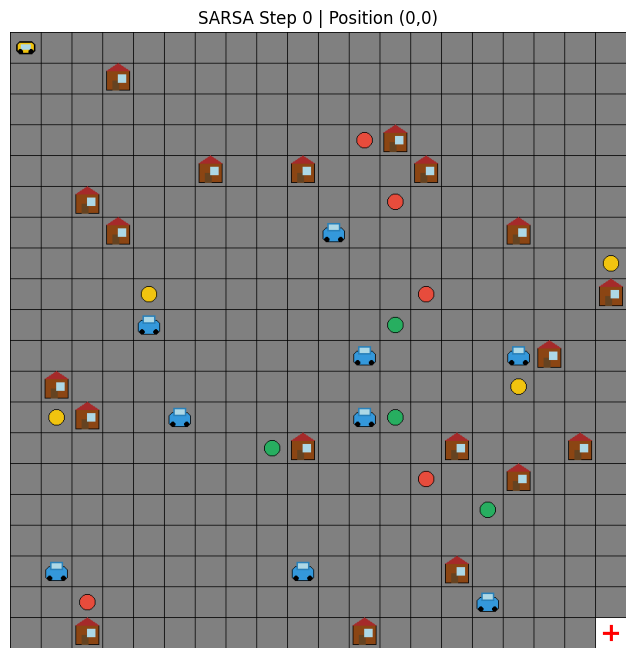

In [9]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Video
import copy

print("Creating SARSA movement visualization...")

# Start
state, _ = env.reset()
done = False

grid_history = [env._grid.copy()]
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]

# Run using SARSA policy
while not done and len(states_history) < 200:
    action = np.argmax(Q[state])   # SARSA learned policy
    state, reward, done, _, _ = env.step(action)

    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())

print("Steps taken:", len(states_history))

# Animation
fig, ax = plt.subplots(figsize=(8, 8))

def update(frame):
    ax.clear()
    env._grid = grid_history[frame]
    img = env.render_frame(states_history[frame], lights_history[frame])
    ax.imshow(img)

    r, c = divmod(states_history[frame], env.cols)
    ax.set_title(f"SARSA Step {frame} | Position ({r},{c})")

    ax.axis('off')

anim = FuncAnimation(fig, update, frames=len(states_history), interval=150)

anim.save('sarsa_demo.mp4', writer='ffmpeg', fps=8)

print("Saved as sarsa_demo.mp4")
Video('sarsa_demo.mp4', embed=True)

In [10]:
# mean
window = 100
means = []

for i in range(0, len(episode_rewards), window):
    means.append(np.mean(episode_rewards[i:i+window]))

print(means)

[np.float64(-289.6), np.float64(-234.97), np.float64(-205.38), np.float64(-167.61), np.float64(-143.02), np.float64(-123.38), np.float64(-67.99), np.float64(-19.41), np.float64(-15.07), np.float64(12.36), np.float64(13.18), np.float64(43.58), np.float64(36.0), np.float64(50.93), np.float64(48.39), np.float64(40.45), np.float64(50.68), np.float64(47.31), np.float64(50.68), np.float64(49.91), np.float64(48.14), np.float64(52.3), np.float64(50.58), np.float64(49.35), np.float64(51.86), np.float64(53.18), np.float64(49.32), np.float64(52.42), np.float64(45.74), np.float64(50.94)]


comparison between actual path and shortest path

In [11]:
def manhattan_distance(start, goal, size):
    sx, sy = start // size, start % size
    gx, gy = goal // size, goal % size
    return abs(sx - gx) + abs(sy - gy)

In [12]:
path = []

state, _ = env.reset()
done = False

while not done:
    action = np.argmax(Q[state])
    next_state, reward, done, _, _ = env.step(action)

    path.append(state)
    state = next_state

In [13]:
start = path[0]
goal = path[-1]

shortest = manhattan_distance(start, goal, env.size)

print("Actual steps:", len(path))
print("Theoretical shortest:", shortest + 1)

Actual steps: 111
Theoretical shortest: 38


#DQN

In [14]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import copy

In [15]:
class DQNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DQNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [40]:
class DQNAgent:
    def __init__(self, env, learning_rate=0.001, gamma=0.97,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 memory_size=10000, batch_size=64, target_update=100):

        self.env = env
        self.n_states = env.size * env.size
        self.n_actions = 4
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.update_counter = 0

        self.state_size = self.n_states

        self.policy_net = DQNetwork(self.state_size, 128, self.n_actions)
        self.target_net = DQNetwork(self.state_size, 128, self.n_actions)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)

        self.memory = deque(maxlen=memory_size)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.best_reward = -float('inf')
        self.best_model = None

    def state_to_tensor(self, state):
        one_hot = np.zeros(self.state_size)
        one_hot[state] = 1
        return torch.FloatTensor(one_hot).unsqueeze(0)

    def choose_action(self, state, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)

        with torch.no_grad():
            state_tensor = self.state_to_tensor(state)
            q_values = self.policy_net(state_tensor)
            return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0

        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array([self.state_to_tensor(s).numpy() for s in states])).squeeze(1)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array([self.state_to_tensor(ns).numpy() for ns in next_states])).squeeze(1)
        dones = torch.FloatTensor(dones)

        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))

        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = nn.MSELoss()(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_counter += 1
        if self.update_counter % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def evaluate(self, episodes=50):
        np.random.seed(69)
        random.seed(69)
        torch.manual_seed(69)

        rewards = []
        success_count = 0

        for _ in range(episodes):
            state, _ = self.env.reset()
            done = False
            total_reward = 0

            while not done:
                action = self.choose_action(state, training=False)
                state, reward, done, _, _ = self.env.step(action)
                total_reward += reward

            rewards.append(total_reward)
            if done and reward == 100:
                success_count += 1

        avg_reward = np.mean(rewards)
        success_rate = success_count / episodes * 100

        print(f"\nDQN Evaluation Results:")
        print(f"Average Reward: {avg_reward:.2f} +/- {np.std(rewards):.2f}")
        print(f"Success Rate: {success_rate:.1f}%")

        return avg_reward, success_rate

    def train(self, episodes=3000, verbose=True):
        episode_rewards = []
        episode_losses = []

        for episode in range(episodes):
            state, _ = self.env.reset()
            total_reward = 0
            done = False
            episode_loss = 0
            step = 0

            while not done and step < 200:
                action = self.choose_action(state, training=True)
                next_state, reward, done, _, _ = self.env.step(action)

                self.remember(state, action, reward, next_state, done)

                loss = self.replay()
                if loss > 0:
                    episode_loss += loss

                state = next_state
                total_reward += reward
                step += 1

            episode_rewards.append(total_reward)
            episode_losses.append(episode_loss / max(step, 1))
            self.decay_epsilon()

            if verbose and episode % 100 == 0:
                avg_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
                print(f"Episode {episode}: Avg Reward = {avg_reward:.2f}, Epsilon = {self.epsilon:.3f}")

                if avg_reward > self.best_reward:
                    self.best_reward = avg_reward
                    self.best_model = self.policy_net.state_dict().copy()
                    print(f"New best model saved! Reward: {self.best_reward:.2f}")

        return episode_rewards, episode_losses

#TRAINING DQN AGENT

In [41]:
print("TRAINING DQN AGENT")
dqn_agent = DQNAgent(
    env,
    learning_rate=0.001,
    gamma=0.97,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    memory_size=10000,
    batch_size=64,
    target_update=100
)
dqn_rewards, dqn_losses = dqn_agent.train(episodes=3000)

TRAINING DQN AGENT
Episode 0: Avg Reward = -284.00, Epsilon = 0.995
New best model saved! Reward: -284.00
Episode 100: Avg Reward = -287.74, Epsilon = 0.603
Episode 200: Avg Reward = -192.19, Epsilon = 0.365
New best model saved! Reward: -192.19
Episode 300: Avg Reward = 12.42, Epsilon = 0.221
New best model saved! Reward: 12.42
Episode 400: Avg Reward = 39.70, Epsilon = 0.134
New best model saved! Reward: 39.70
Episode 500: Avg Reward = 39.75, Epsilon = 0.081
New best model saved! Reward: 39.75
Episode 600: Avg Reward = 41.38, Epsilon = 0.049
New best model saved! Reward: 41.38
Episode 700: Avg Reward = 48.12, Epsilon = 0.030
New best model saved! Reward: 48.12
Episode 800: Avg Reward = 46.22, Epsilon = 0.018
Episode 900: Avg Reward = 46.85, Epsilon = 0.011
Episode 1000: Avg Reward = 49.83, Epsilon = 0.010
New best model saved! Reward: 49.83
Episode 1100: Avg Reward = 50.56, Epsilon = 0.010
New best model saved! Reward: 50.56
Episode 1200: Avg Reward = 49.62, Epsilon = 0.010
Episode 1

# Save best model

In [42]:
if dqn_agent.best_model is not None:
    torch.save(dqn_agent.best_model, 'best_dqn_model.pth')
    print(f"Best DQN model saved! Best reward: {dqn_agent.best_reward:.2f}")
else:
    torch.save(dqn_agent.policy_net.state_dict(), 'best_dqn_model.pth')
    print("DQN model saved as 'best_dqn_model.pth'")
print("Model saved successfully!")

Best DQN model saved! Best reward: 52.24
Model saved successfully!


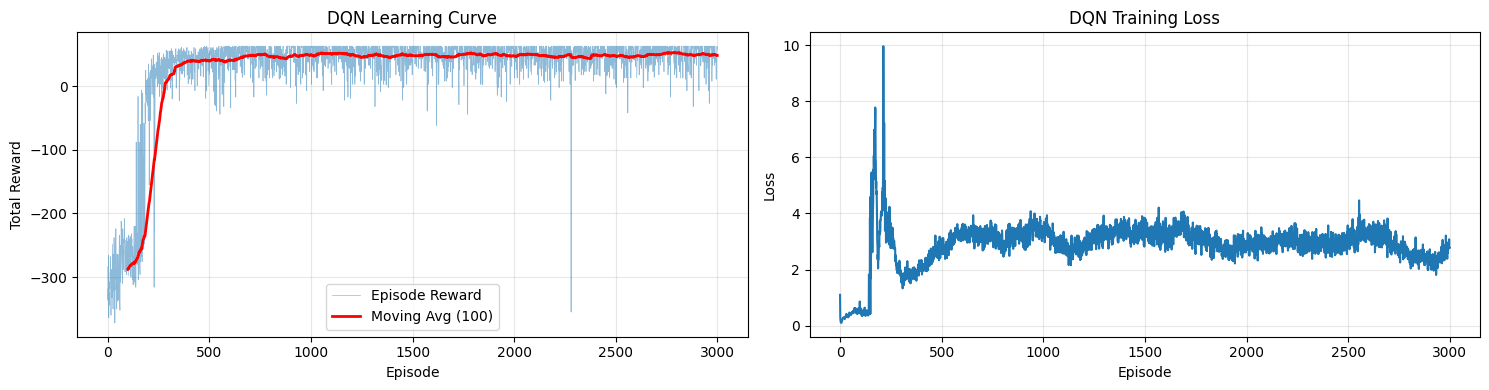

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(dqn_rewards, alpha=0.5, linewidth=0.5, label='Episode Reward')
window = 100
moving_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
axes[0].plot(range(window-1, len(dqn_rewards)), moving_avg, 'r-', linewidth=2, label=f'Moving Avg ({window})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('DQN Learning Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(dqn_losses)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].set_title('DQN Training Loss')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dqn_training_curves.png', dpi=150)
plt.show()

# Load best model

In [44]:
best_dqn = DQNAgent(env)
best_dqn.policy_net.load_state_dict(torch.load('best_dqn_model.pth'))
best_dqn.target_net.load_state_dict(best_dqn.policy_net.state_dict())
print("Best DQN model loaded for evaluation")

Best DQN model loaded for evaluation


#EVALUATION - DQN

In [49]:
print("EVALUATION - DQN")
np.random.seed(69)
random.seed(69)
torch.manual_seed(69)
if dqn_agent.best_model is not None:
    best_dqn.policy_net.load_state_dict(dqn_agent.best_model)
dqn_final_score, dqn_success_rate = best_dqn.evaluate(episodes=50)
print(f"DQN Score: {dqn_final_score:.2f}")

EVALUATION - DQN

DQN Evaluation Results:
Average Reward: 52.80 +/- 15.68
Success Rate: 100.0%
DQN Score: 52.80


#Testing DQN with Animation

CREATING DQN NAVIGATION VIDEO
Steps taken: 38
Reached hospital: True
Saved as 'dqn_navigation.mp4'


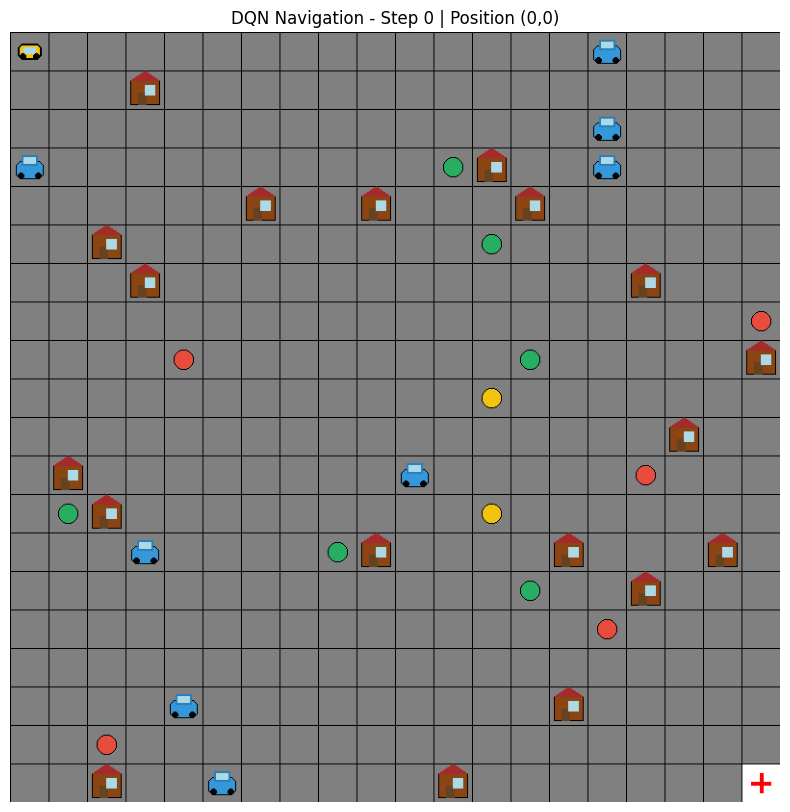

In [50]:
print("CREATING DQN NAVIGATION VIDEO")
state, _ = env.reset()
done = False
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]
grid_history = [env._grid.copy()]

while not done and len(states_history) < 200:
    action = best_dqn.choose_action(state, training=False)
    state, reward, done, _, _ = env.step(action)

    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())

print(f"Steps taken: {len(states_history)-1}")
print(f"Reached hospital: {done}")

fig, ax = plt.subplots(figsize=(10, 10))

def update(frame):
    ax.clear()
    env._grid = grid_history[frame]
    frame_img = env.render_frame(states_history[frame], lights_history[frame])
    ax.imshow(frame_img)
    r, c = divmod(states_history[frame], env.cols)
    ax.set_title(f'DQN Navigation - Step {frame} | Position ({r},{c})')
    ax.axis('off')
    return ax

anim = FuncAnimation(fig, update, frames=len(states_history), interval=150, repeat=False)
anim.save('dqn_navigation.mp4', writer='ffmpeg', fps=8)
print("Saved as 'dqn_navigation.mp4'")

from IPython.display import Video
Video('dqn_navigation.mp4', embed=True, width=800, height=800)

#Q-learning

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from matplotlib.animation import FuncAnimation

In [52]:
class QLearningAgent:

    def __init__(self, env, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):

        self.env = env
        self.alpha = alpha
        self.gamma = gamma

        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.q_table = np.zeros((env.observation_space.n,
                                 env.action_space.n))

    def choose_action(self, state):

        if random.random() < self.epsilon:
            return self.env.action_space.sample()

        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state, done):

        best_next = np.max(self.q_table[next_state])

        target = reward + (0 if done else self.gamma * best_next)

        self.q_table[state, action] += self.alpha * (
            target - self.q_table[state, action]
        )

    def decay_epsilon(self):

        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

In [53]:
def train_q_learning(env, agent, episodes=3000):

    rewards = []

    print("===== Q-LEARNING TRAINING =====")

    for ep in range(episodes):

        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:

            action = agent.choose_action(state)
            next_state, reward, done, _, _ = env.step(action)

            agent.learn(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

        agent.decay_epsilon()

        rewards.append(total_reward)

        avg = np.mean(rewards[-50:])

        print(f"Episode {ep+1:4d} | Reward: {total_reward:6.2f} | "
              f"Avg(50): {avg:6.2f} | Epsilon: {agent.epsilon:.3f}")

    return rewards

In [54]:
print("START TRAINING Q-LEARNING AGENT")

ql_agent = QLearningAgent(env)

ql_rewards = train_q_learning(env, ql_agent, episodes=3000)

START TRAINING Q-LEARNING AGENT
===== Q-LEARNING TRAINING =====
Episode    1 | Reward: -1409.00 | Avg(50): -1409.00 | Epsilon: 0.995
Episode    2 | Reward: -1069.00 | Avg(50): -1239.00 | Epsilon: 0.990
Episode    3 | Reward: -1080.00 | Avg(50): -1186.00 | Epsilon: 0.985
Episode    4 | Reward: -720.00 | Avg(50): -1069.50 | Epsilon: 0.980
Episode    5 | Reward: -5528.00 | Avg(50): -1961.20 | Epsilon: 0.975
Episode    6 | Reward: -4343.00 | Avg(50): -2358.17 | Epsilon: 0.970
Episode    7 | Reward: -3561.00 | Avg(50): -2530.00 | Epsilon: 0.966
Episode    8 | Reward: -2584.00 | Avg(50): -2536.75 | Epsilon: 0.961
Episode    9 | Reward: -11475.00 | Avg(50): -3529.89 | Epsilon: 0.956
Episode   10 | Reward: -3551.00 | Avg(50): -3532.00 | Epsilon: 0.951
Episode   11 | Reward: -641.00 | Avg(50): -3269.18 | Epsilon: 0.946
Episode   12 | Reward: -11669.00 | Avg(50): -3969.17 | Epsilon: 0.942
Episode   13 | Reward: -8936.00 | Avg(50): -4351.23 | Epsilon: 0.937
Episode   14 | Reward: -1523.00 | Avg(5

In [55]:
import numpy as np

np.save("q_table.npy", ql_agent.q_table)

print("Q-table saved successfully")

Q-table saved successfully


In [56]:
# ============================================
#  EVALUATION
# ============================================

def evaluate_q_learning(env, agent, episodes=50):

    rewards = []
    success = 0

    for _ in range(episodes):

        state, _ = env.reset()
        done = False
        total = 0

        while not done:

            action = np.argmax(agent.q_table[state])
            state, reward, done, _, _ = env.step(action)

            total += reward

        rewards.append(total)

        if total > 0:
            success += 1

    avg_reward = np.mean(rewards)
    success_rate = success / episodes * 100

    print("\n===== Q-LEARNING EVALUATION =====")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Success Rate: {success_rate:.1f}%")

    return avg_reward, success_rate, rewards

In [58]:
def random_policy(env, episodes=50):

    rewards = []

    for _ in range(episodes):

        state, _ = env.reset()
        done = False
        total = 0

        while not done:

            action = env.action_space.sample()
            state, reward, done, _, _ = env.step(action)

            total += reward

        rewards.append(total)

    return np.mean(rewards), rewards


print("===== BEFORE VS AFTER =====")

before_score, before_rewards = random_policy(env)
after_score, after_rewards, _ = evaluate_q_learning(env, ql_agent)

print(f"Before Training: {before_score:.2f}")
print(f"After Training : {after_score:.2f}")

===== BEFORE VS AFTER =====

===== Q-LEARNING EVALUATION =====
Average Reward: 51.60
Success Rate: 98.0%
Before Training: -4363.52
After Training : 51.60


In [59]:
import copy

state, _ = env.reset()
done = False

grid_history = [env._grid.copy()]
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]

while not done and len(states_history) < 200:

    action = np.argmax(ql_agent.q_table[state])
    state, reward, done, _, _ = env.step(action)

    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())


In [60]:
import imageio.v2 as imageio
from IPython.display import Video

frames = []

for i in range(len(states_history)):
    env._grid = grid_history[i]
    frames.append(env.render_frame(states_history[i],
                                   lights_history[i]))

imageio.mimsave("qlearning_video.mp4", frames, fps=8)

Video("qlearning_video.mp4", embed=True)

In [61]:
print("===== COMPARISON =====")

print(f"SARSA       : {sarsa_score:.2f}")
print(f"DQN         : {dqn_final_score:.2f}")
print(f"Q-Learning  : {after_score:.2f}")


===== COMPARISON =====
SARSA       : 51.80
DQN         : 52.80
Q-Learning  : 51.60


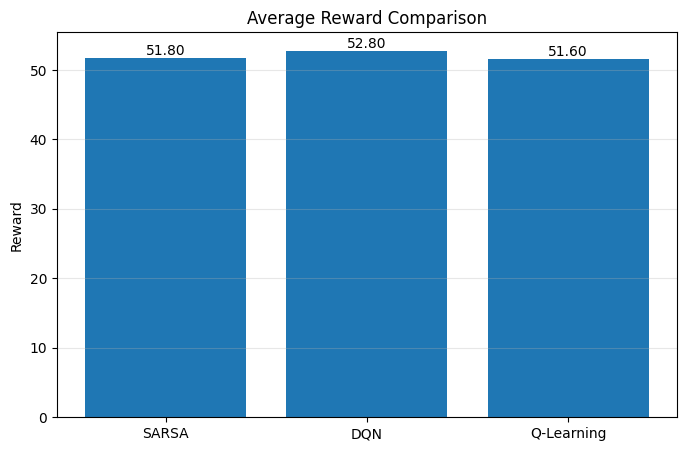

In [62]:
algorithms = ["SARSA","DQN", "Q-Learning" ]
scores = [sarsa_score, dqn_final_score, after_score]

plt.figure(figsize=(8,5))
bars = plt.bar(algorithms, scores)

plt.title("Average Reward Comparison")
plt.ylabel("Reward")
plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{val:.2f}",
             ha='center', va='bottom')

plt.show()

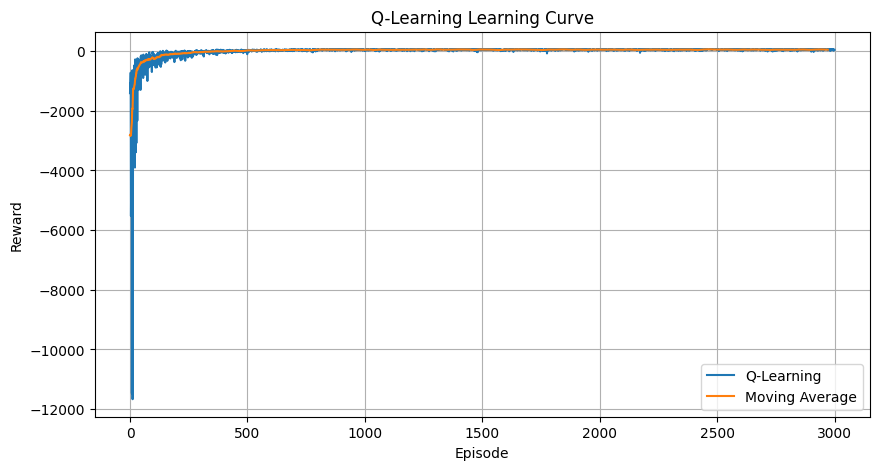

In [63]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

plt.plot(ql_rewards, label="Q-Learning")
plt.plot(np.convolve(ql_rewards, np.ones(30)/30, mode='valid'),
         label="Moving Average")

plt.title("Q-Learning Learning Curve")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.legend()
plt.grid()
plt.show()